<a href="https://colab.research.google.com/github/RomaParakh/digital-distraction-academic-performance/blob/main/eda_model_digital_distraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import matplotlib.ticker as mticker

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#F7F9FC",
    "axes.facecolor":   "#F7F9FC",
    "axes.edgecolor":   "#CCCCCC",
    "axes.labelcolor":  "#333333",
    "xtick.color":      "#555555",
    "ytick.color":      "#555555",
    "text.color":       "#333333",
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "axes.grid":        True,
    "grid.color":       "#E0E0E0",
    "grid.linewidth":   0.6,
    "axes.spines.top":  False,
    "axes.spines.right":False,
})

PALETTE_CAT  = ["#2E86AB", "#E84855", "#F4A261", "#3BB273", "#8338EC"]
ACCENT       = "#2E86AB"
HIGHLIGHT    = "#E84855"


In [ ]:
# Load the dataset
import pandas as pd
dataset = pd.read_csv("/content/student_digital_life.csv")
df = dataset
df.head()

,student_id,age,gender,study_hours_per_day,smartphone_usage_hours,social_media_hours,gaming_hours,streaming_hours,sleep_hours,exercise_hours,class_attendance_percent,assignment_completion_percent,caffeine_intake_cups,mental_health_status,parent_education_level,internet_quality,motivation_level,final_exam_score
0,1,21,Female,3.01,0.26,1.77,0.26,1.71,5.32,0.70,64.87,74.11,2,Good,Masters,Average,6.32,82.70
1,2,23,Female,5.84,8.02,3.30,0.96,0.00,5.99,1.99,85.38,80.68,3,Average,Masters,Poor,2.52,85.65
2,3,20,Female,7.80,10.13,0.00,2.23,2.54,6.36,1.82,76.15,79.69,2,Good,HighSchool,Poor,3.98,88.14
3,4,20,Female,0.00,1.15,1.32,4.19,0.27,7.86,0.18,84.41,79.07,0,Average,HighSchool,Average,4.77,54.81
4,5,24,Male,7.23,1.39,2.21,4.67,2.75,7.88,0.28,81.13,65.40,4,Good,HighSchool,Average,8.77,84.34


In [ ]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(15000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     15000 non-null  int64  
 1   age                            15000 non-null  int64  
 2   gender                         15000 non-null  object 
 3   study_hours_per_day            15000 non-null  float64
 4   smartphone_usage_hours         15000 non-null  float64
 5   social_media_hours             15000 non-null  float64
 6   gaming_hours                   15000 non-null  float64
 7   streaming_hours                15000 non-null  float64
 8   sleep_hours                    15000 non-null  float64
 9   exercise_hours                 15000 non-null  float64
 10  class_attendance_percent       15000 non-null  float64
 11  assignment_completion_percent  15000 non-null  float64
 12  caffeine_intake_cups           150

In [ ]:
df1 = df.copy()

In [ ]:
df.drop(columns=["student_id"], inplace=True)
print("\n[1] Dropped 'student_id' — not useful for analysis.")


[1] Dropped 'student_id' — not useful for analysis.


In [ ]:
# Caffeine had 1,001 outliers (7% of data); other columns had <1% — kept.
Q1 = df["caffeine_intake_cups"].quantile(0.25)
Q3 = df["caffeine_intake_cups"].quantile(0.75)
IQR = Q3 - Q1
upper_cap = Q3 + 1.5 * IQR
before = (df["caffeine_intake_cups"] > upper_cap).sum()
df["caffeine_intake_cups"] = df["caffeine_intake_cups"].clip(upper=upper_cap)
print(f"\n[3] Capped {before} outliers in 'caffeine_intake_cups' at {upper_cap:.0f} cups (IQR method).")
print("    Other numeric columns: outliers <1% of data — retained (real-world noise).")



[3] Capped 1001 outliers in 'caffeine_intake_cups' at 4 cups (IQR method).
    Other numeric columns: outliers <1% of data — retained (real-world noise).


In [ ]:
# Drop rows with extreme / impossible final exam scores
before_rows = len(df)
df = df[df["final_exam_score"].between(0, 100)]
dropped = before_rows - len(df)
print(f"\n[4] Removed {dropped} rows where final_exam_score outside [0, 100].")


[4] Removed 0 rows where final_exam_score outside [0, 100].


In [ ]:
df["mental_health_status"] = pd.Categorical(
    df["mental_health_status"], categories=["Poor", "Average", "Good"], ordered=True)
df["internet_quality"] = pd.Categorical(
    df["internet_quality"], categories=["Poor", "Average", "Good"], ordered=True)
df["parent_education_level"] = pd.Categorical(
    df["parent_education_level"],
    categories=["HighSchool", "Bachelors", "Masters", "PhD"], ordered=True)
print("\n[5] Set ordinal order: mental_health_status, internet_quality, parent_education_level.")


[5] Set ordinal order: mental_health_status, internet_quality, parent_education_level.


In [ ]:
# Feature engineering — total screen time
df["total_screen_hours"] = (df["smartphone_usage_hours"]
                            + df["social_media_hours"]
                            + df["gaming_hours"]
                            + df["streaming_hours"])
print("\n[6] Created 'total_screen_hours' = smartphone + social_media + gaming + streaming.")


[6] Created 'total_screen_hours' = smartphone + social_media + gaming + streaming.


In [ ]:
df["screen_time_tier"] = pd.cut(
    df["total_screen_hours"],
    bins=[0, 4, 7, 11, 100],
    labels=["Low (<4h)", "Moderate (4–7h)", "High (7–11h)", "Very High (>11h)"]
)
print("\n[7] Created 'screen_time_tier' — Low / Moderate / High / Very High.\n")

print(f"▶ Clean dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")



[7] Created 'screen_time_tier' — Low / Moderate / High / Very High.

▶ Clean dataset shape : 15,000 rows × 19 columns


In [ ]:
df["score_tier"] = pd.cut(df["final_exam_score"],
    bins=[0, 50, 70, 85, 100],
    labels=["Failing (<50)", "Below Avg (50–70)", "Average (70–85)", "High (85–100)"])

In [ ]:
# Ordinal encode the two remaining useful categoricals
ordinal_map = {"Poor": 0, "Average": 1, "Good": 2}

df["mental_health_encoded"]    = df["mental_health_status"].map(ordinal_map)
df["internet_quality_encoded"] = df["internet_quality"].map(ordinal_map)


In [ ]:
NUM_COLS = [
    "study_hours_per_day", "sleep_hours", "smartphone_usage_hours",
    "social_media_hours", "gaming_hours", "streaming_hours",
    "exercise_hours", "motivation_level", "class_attendance_percent",
    "assignment_completion_percent", "caffeine_intake_cups",
    "total_screen_hours", "final_exam_score",
    "mental_health_encoded", "internet_quality_encoded"   # ← added
]

In [ ]:
# Summary stats
print("\n" + "─" * 65)
print(" SUMMARY STATISTICS")
print("─" * 65)
summary = df[NUM_COLS].describe().T.round(2)
print(summary)


─────────────────────────────────────────────────────────────────
 SUMMARY STATISTICS
─────────────────────────────────────────────────────────────────
                                 count   mean    std    min    25%    50%  \
study_hours_per_day            15000.0   4.51   1.98   0.00   3.17   4.51   
sleep_hours                    15000.0   7.00   1.46   3.50   5.97   6.99   
smartphone_usage_hours         15000.0   5.50   2.44   0.00   3.83   5.48   
social_media_hours             15000.0   3.52   1.77   0.00   2.28   3.49   
gaming_hours                   15000.0   2.24   1.47   0.00   1.11   2.17   
streaming_hours                15000.0   1.83   1.13   0.00   0.99   1.78   
exercise_hours                 15000.0   1.23   0.83   0.00   0.60   1.19   
motivation_level               15000.0   5.99   1.95   1.00   4.65   6.00   
class_attendance_percent       15000.0  84.63   9.45  44.96  78.18  84.90   
assignment_completion_percent  15000.0  79.45  13.92  30.00  70.01  80.22   


In [ ]:
df[NUM_COLS].describe().to_excel('summary_stats.xlsx')

In [ ]:
print("\n" + "─" * 65)
print("  2D — CORRELATION TABLE")
print("─" * 65)
CORR_COLS = [
    "study_hours_per_day", "sleep_hours", "smartphone_usage_hours",
    "social_media_hours", "gaming_hours", "streaming_hours",
    "exercise_hours", "motivation_level", "class_attendance_percent",
    "assignment_completion_percent", "total_screen_hours", "final_exam_score"
]
CORR_LABELS = [
    "Study Hrs", "Sleep Hrs", "Smartphone", "Social Media", "Gaming",
    "Streaming", "Exercise", "Motivation", "Attendance",
    "Assignments", "Total Screen", "Exam Score"
]

corr_matrix = df[CORR_COLS].corr()
print("\nTop correlations with final_exam_score:")
print(corr_matrix["final_exam_score"].sort_values(ascending=False).round(3).to_string())


─────────────────────────────────────────────────────────────────
  2D — CORRELATION TABLE
─────────────────────────────────────────────────────────────────

Top correlations with final_exam_score:
final_exam_score                 1.000
study_hours_per_day              0.644
assignment_completion_percent    0.200
motivation_level                 0.156
class_attendance_percent         0.142
sleep_hours                      0.073
exercise_hours                   0.050
social_media_hours               0.004
streaming_hours                 -0.034
gaming_hours                    -0.087
total_screen_hours              -0.141
smartphone_usage_hours          -0.142


In [ ]:
corr_matrix = df[CORR_COLS].corr().to_excel('corr.xlsx')

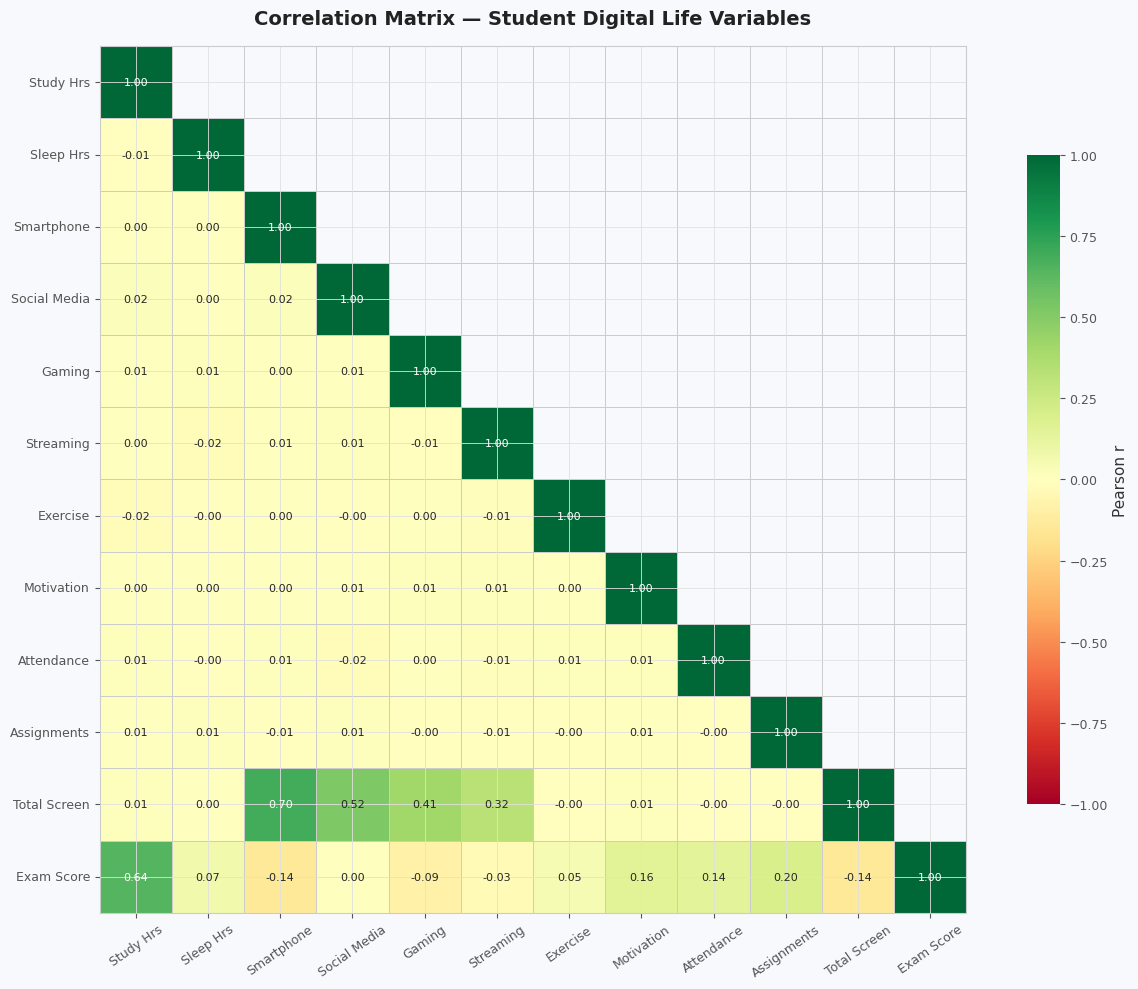

In [ ]:
fig_corr, ax_corr = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="#CCCCCC",
    square=True,
    ax=ax_corr,
    xticklabels=CORR_LABELS,
    yticklabels=CORR_LABELS,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.75, "label": "Pearson r"}
)
ax_corr.set_title("Correlation Matrix — Student Digital Life Variables",
                  fontsize=14, fontweight="bold", pad=16, color="#222222")
ax_corr.tick_params(axis="x", rotation=35, labelsize=9)
ax_corr.tick_params(axis="y", rotation=0, labelsize=9)

# Highlight exam score row/column border
for spine in ax_corr.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("#CCCCCC")

plt.tight_layout()
plt.show()


In [ ]:
print("\n" + "=" * 65)
print("  PART 3 — DASHBOARD VISUALIZATIONS")
print("=" * 65)


  PART 3 — DASHBOARD VISUALIZATIONS


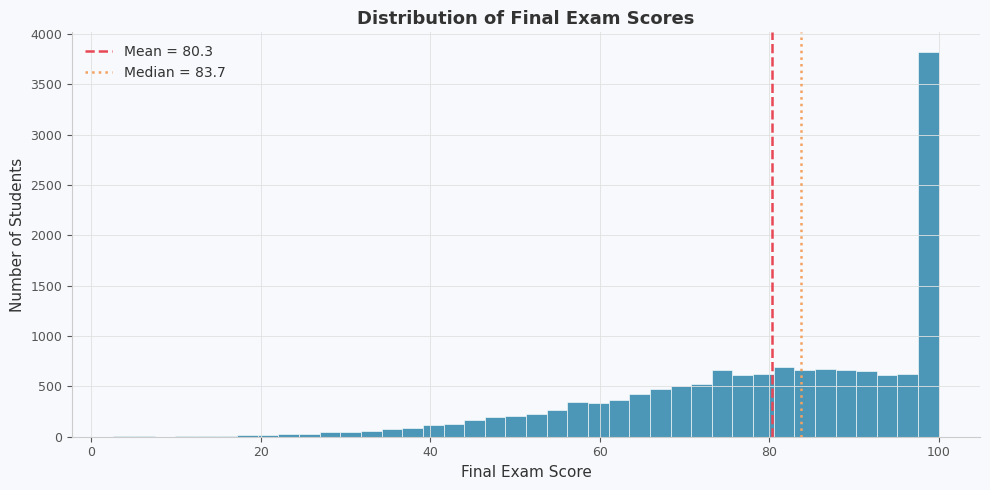

In [ ]:
# Distribution of Final Exam Score

fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.hist(df["final_exam_score"], bins=40, color=ACCENT, edgecolor="white",
         linewidth=0.5, alpha=0.85)
ax1.axvline(df["final_exam_score"].mean(), color=HIGHLIGHT, linestyle="--",
            linewidth=1.8, label=f"Mean = {df['final_exam_score'].mean():.1f}")
ax1.axvline(df["final_exam_score"].median(), color="#F4A261", linestyle=":",
            linewidth=1.8, label=f"Median = {df['final_exam_score'].median():.1f}")
ax1.set_xlabel("Final Exam Score")
ax1.set_ylabel("Number of Students")
ax1.set_title("Distribution of Final Exam Scores", fontweight="bold")
ax1.legend(frameon=False)
plt.tight_layout()
plt.show()

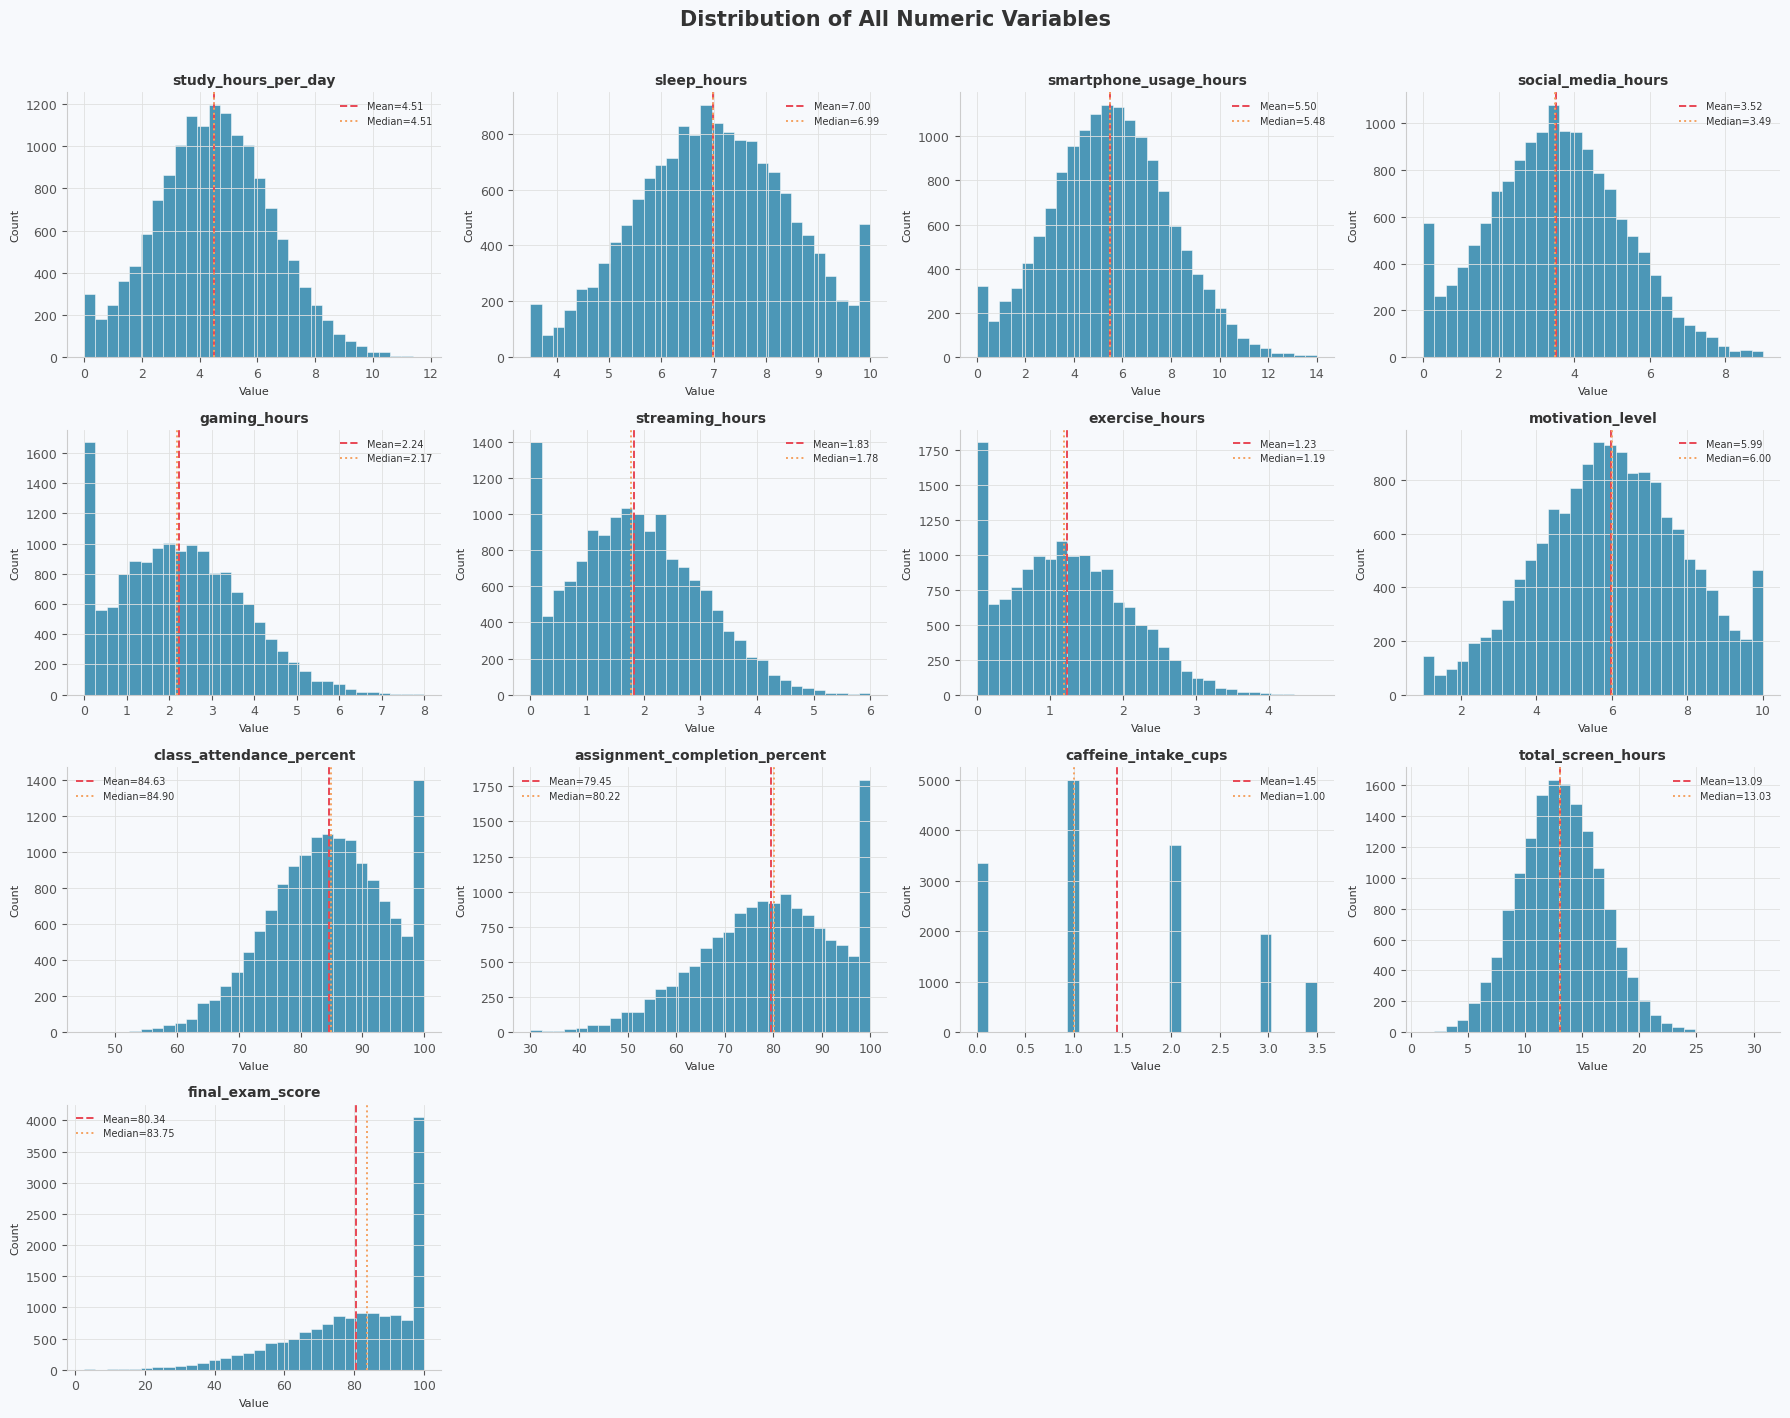

In [ ]:
# Distribution of numeric columns
PLOT_COLS = [col for col in NUM_COLS if pd.api.types.is_numeric_dtype(df[col])]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(PLOT_COLS):
    axes[i].hist(df[col], bins=30, color=ACCENT, edgecolor="white", linewidth=0.4, alpha=0.85)
    axes[i].axvline(df[col].mean(), color=HIGHLIGHT, linestyle="--", linewidth=1.4,
                    label=f"Mean={df[col].mean():.2f}")
    axes[i].axvline(df[col].median(), color="#F4A261", linestyle=":", linewidth=1.4,
                    label=f"Median={df[col].median():.2f}")
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Value", fontsize=8)
    axes[i].set_ylabel("Count", fontsize=8)
    axes[i].legend(fontsize=7, frameon=False)

for j in range(len(PLOT_COLS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribution of All Numeric Variables", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

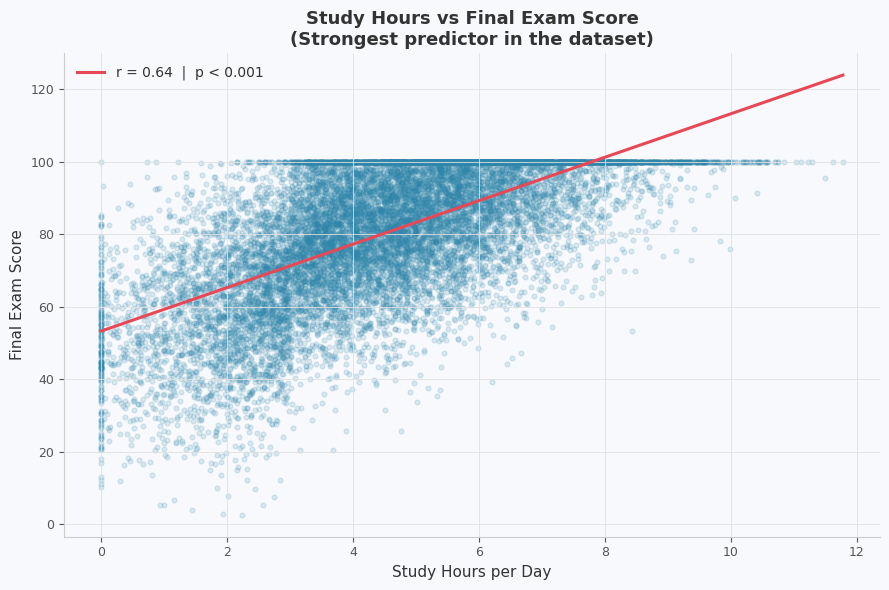

In [ ]:
# Study Hours vs Final Exam Score
fig2, ax2 = plt.subplots(figsize=(9, 6))
ax2.scatter(df["study_hours_per_day"], df["final_exam_score"],
            alpha=0.15, s=12, color=ACCENT, rasterized=True)

# Regression line
m, b, r, p, _ = stats.linregress(df["study_hours_per_day"], df["final_exam_score"])
x_line = np.linspace(df["study_hours_per_day"].min(), df["study_hours_per_day"].max(), 200)
ax2.plot(x_line, m * x_line + b, color=HIGHLIGHT, linewidth=2.2,
         label=f"r = {r:.2f}  |  p < 0.001")

ax2.set_xlabel("Study Hours per Day")
ax2.set_ylabel("Final Exam Score")
ax2.set_title("Study Hours vs Final Exam Score\n(Strongest predictor in the dataset)", fontweight="bold")
ax2.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()


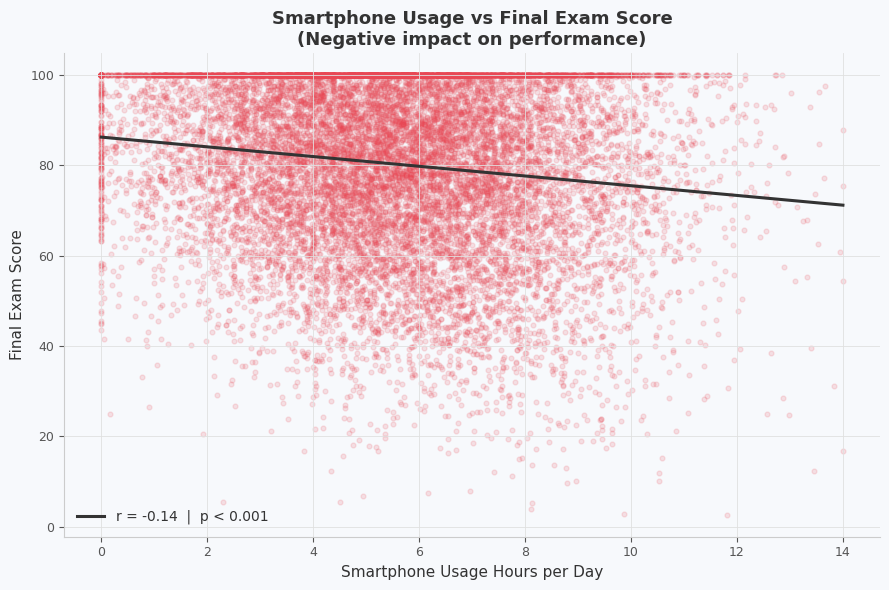

In [ ]:
# Smartphone Usage vs Final Exam Score
fig3, ax3 = plt.subplots(figsize=(9, 6))
ax3.scatter(df["smartphone_usage_hours"], df["final_exam_score"],
            alpha=0.15, s=12, color="#E84855", rasterized=True)

m2, b2, r2, p2, _ = stats.linregress(df["smartphone_usage_hours"], df["final_exam_score"])
x2 = np.linspace(df["smartphone_usage_hours"].min(), df["smartphone_usage_hours"].max(), 200)
ax3.plot(x2, m2 * x2 + b2, color="#333333", linewidth=2.2,
         label=f"r = {r2:.2f}  |  p < 0.001")

ax3.set_xlabel("Smartphone Usage Hours per Day")
ax3.set_ylabel("Final Exam Score")
ax3.set_title("Smartphone Usage vs Final Exam Score\n(Negative impact on performance)", fontweight="bold")
ax3.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

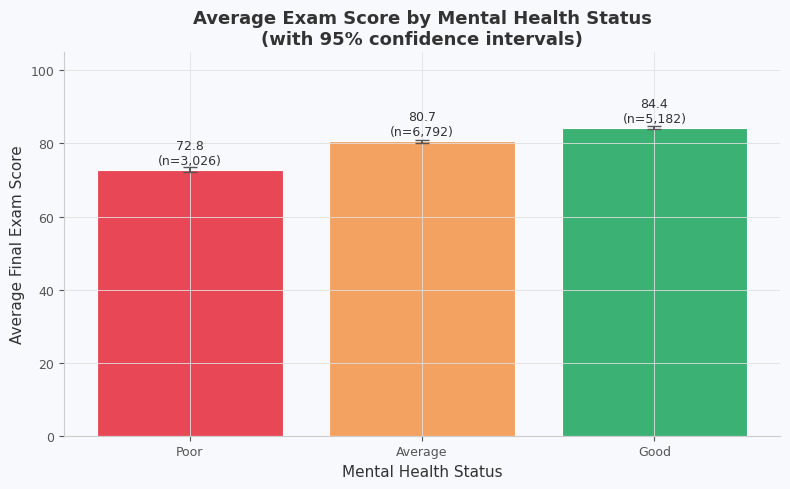

In [ ]:
# Average Exam Score by Mental Health Status
mh_avg = (df.groupby("mental_health_status", observed=True)["final_exam_score"]
          .agg(["mean", "sem", "count"]).reset_index())

fig4, ax4 = plt.subplots(figsize=(8, 5))
bars = ax4.bar(
    mh_avg["mental_health_status"].astype(str),
    mh_avg["mean"],
    color=["#E84855", "#F4A261", "#3BB273"],
    edgecolor="white", linewidth=0.8,
    yerr=mh_avg["sem"] * 1.96,
    capsize=5, error_kw={"elinewidth": 1.4, "ecolor": "#555555"}
)
for bar, val, n in zip(bars, mh_avg["mean"], mh_avg["count"]):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
             f"{val:.1f}\n(n={n:,})", ha="center", va="bottom", fontsize=9, color="#333333")

ax4.set_xlabel("Mental Health Status")
ax4.set_ylabel("Average Final Exam Score")
ax4.set_title("Average Exam Score by Mental Health Status\n(with 95% confidence intervals)", fontweight="bold")
ax4.set_ylim(0, 105)
plt.tight_layout()
plt.show()

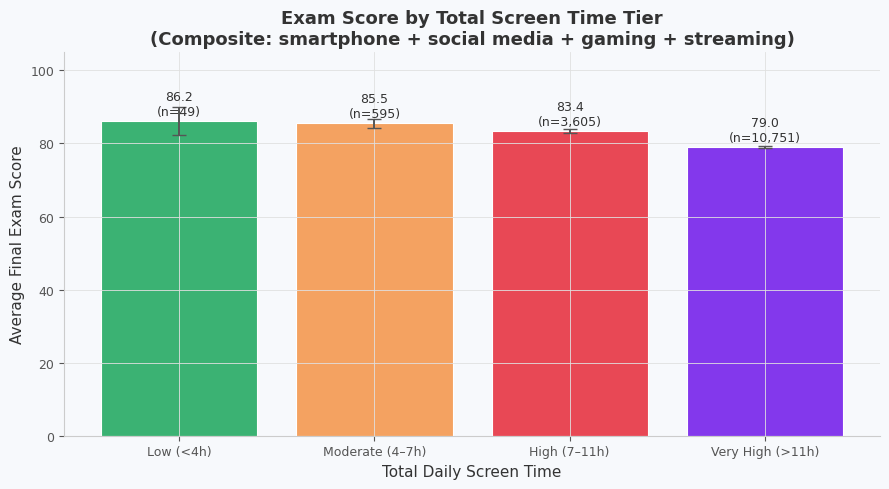

In [ ]:
#Average Exam Score by Screen Time Tier
tier_avg = (df.groupby("screen_time_tier", observed=True)["final_exam_score"]
            .agg(["mean", "sem", "count"]).reset_index())

fig5, ax5 = plt.subplots(figsize=(9, 5))
colors5 = ["#3BB273", "#F4A261", "#E84855", "#8338EC"]
bars5 = ax5.bar(
    tier_avg["screen_time_tier"].astype(str),
    tier_avg["mean"],
    color=colors5,
    edgecolor="white", linewidth=0.8,
    yerr=tier_avg["sem"] * 1.96,
    capsize=5, error_kw={"elinewidth": 1.4, "ecolor": "#555555"}
)
for bar, val, n in zip(bars5, tier_avg["mean"], tier_avg["count"]):
    ax5.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
             f"{val:.1f}\n(n={n:,})", ha="center", va="bottom", fontsize=9)

ax5.set_xlabel("Total Daily Screen Time")
ax5.set_ylabel("Average Final Exam Score")
ax5.set_title("Exam Score by Total Screen Time Tier\n(Composite: smartphone + social media + gaming + streaming)", fontweight="bold")
ax5.set_ylim(0, 105)
plt.tight_layout()
plt.show()

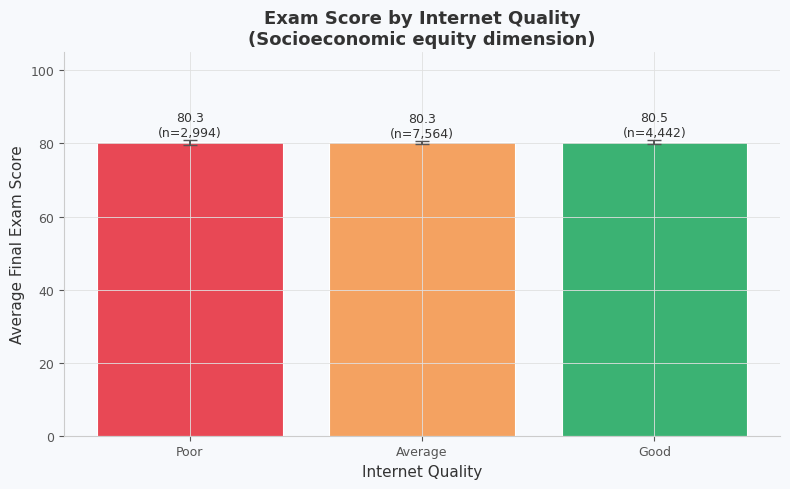

In [ ]:
# Exam Score by Internet Quality
iq_avg = (df.groupby("internet_quality", observed=True)["final_exam_score"]
          .agg(["mean", "sem", "count"]).reset_index())

fig6, ax6 = plt.subplots(figsize=(8, 5))
bars6 = ax6.bar(
    iq_avg["internet_quality"].astype(str),
    iq_avg["mean"],
    color=["#E84855", "#F4A261", "#3BB273"],
    edgecolor="white", linewidth=0.8,
    yerr=iq_avg["sem"] * 1.96,
    capsize=5, error_kw={"elinewidth": 1.4, "ecolor": "#555555"}
)
for bar, val, n in zip(bars6, iq_avg["mean"], iq_avg["count"]):
    ax6.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
             f"{val:.1f}\n(n={n:,})", ha="center", va="bottom", fontsize=9)

ax6.set_xlabel("Internet Quality")
ax6.set_ylabel("Average Final Exam Score")
ax6.set_title("Exam Score by Internet Quality\n(Socioeconomic equity dimension)", fontweight="bold")
ax6.set_ylim(0, 105)
plt.tight_layout()
plt.show()

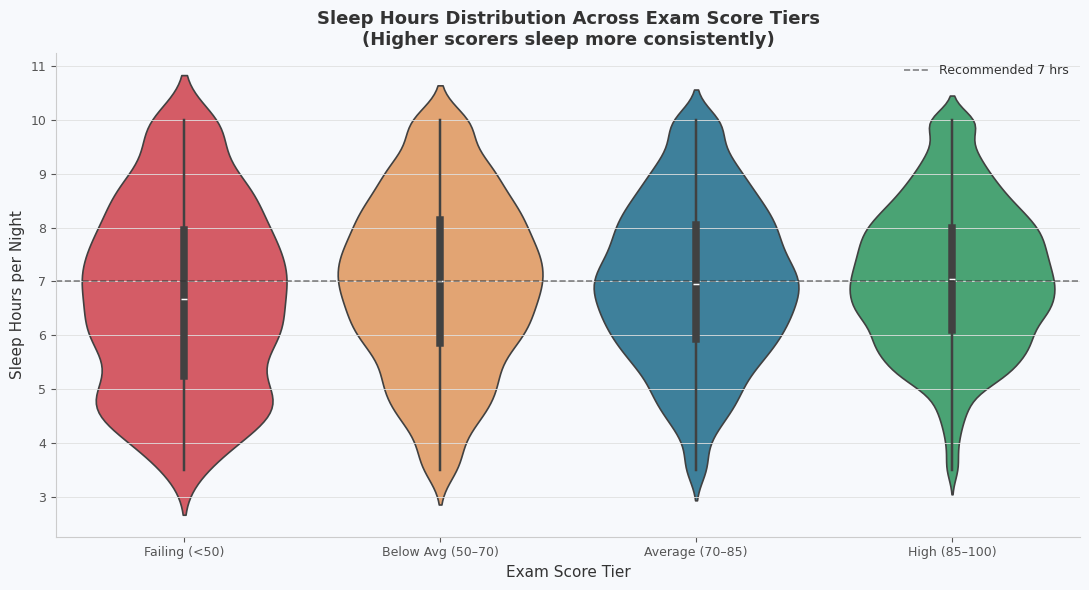

In [ ]:
#Sleep Hours Distribution by Score Tier (violin)
df["score_tier"] = pd.cut(df["final_exam_score"], bins=[0, 50, 70, 85, 100],
                          labels=["Failing (<50)", "Below Avg (50–70)",
                                  "Average (70–85)", "High (85–100)"])

fig7, ax7 = plt.subplots(figsize=(11, 6))
score_order = ["Failing (<50)", "Below Avg (50–70)", "Average (70–85)", "High (85–100)"]
vp = sns.violinplot(data=df, x="score_tier", y="sleep_hours", order=score_order,
                    palette=["#E84855", "#F4A261", "#2E86AB", "#3BB273"],
                    inner="box", linewidth=1.2, ax=ax7)
ax7.axhline(7, color="#333333", linestyle="--", linewidth=1.2,
            alpha=0.6, label="Recommended 7 hrs")
ax7.set_xlabel("Exam Score Tier")
ax7.set_ylabel("Sleep Hours per Night")
ax7.set_title("Sleep Hours Distribution Across Exam Score Tiers\n(Higher scorers sleep more consistently)", fontweight="bold")
ax7.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


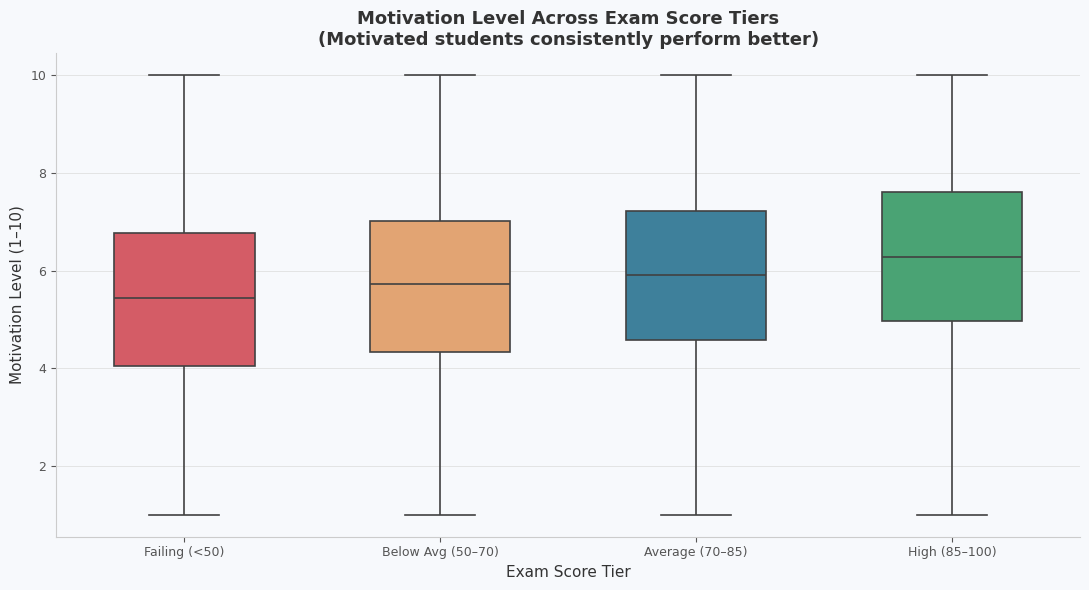

In [ ]:
#Motivation Level vs Exam Score (box plot by score tier)
fig8, ax8 = plt.subplots(figsize=(11, 6))
sns.boxplot(data=df, x="score_tier", y="motivation_level", order=score_order,
            palette=["#E84855", "#F4A261", "#2E86AB", "#3BB273"],
            width=0.55, linewidth=1.2, fliersize=2.5, ax=ax8)
ax8.set_xlabel("Exam Score Tier")
ax8.set_ylabel("Motivation Level (1–10)")
ax8.set_title("Motivation Level Across Exam Score Tiers\n(Motivated students consistently perform better)", fontweight="bold")
plt.tight_layout()
plt.show()

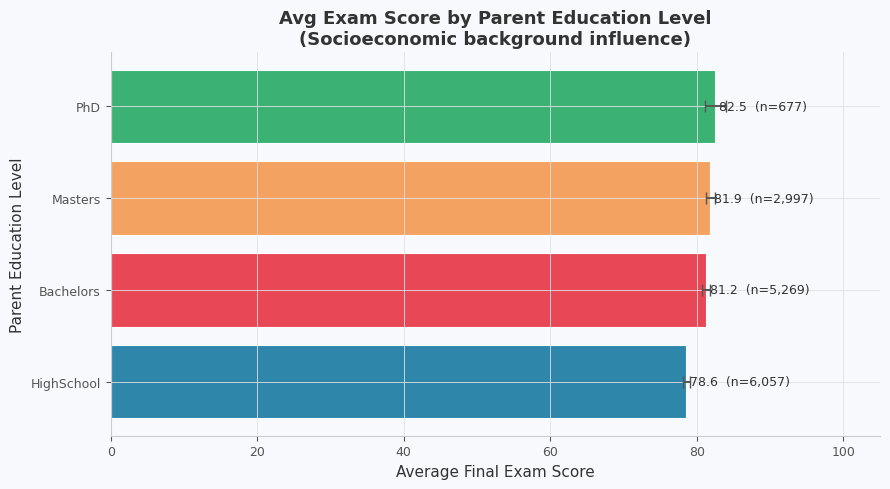

In [ ]:
# Avg Exam Score by Parent Education Level
pe_avg = (df.groupby("parent_education_level", observed=True)["final_exam_score"]
          .agg(["mean", "sem", "count"]).reset_index())

fig9, ax9 = plt.subplots(figsize=(9, 5))
bars9 = ax9.barh(
    pe_avg["parent_education_level"].astype(str),
    pe_avg["mean"],
    color=PALETTE_CAT[:4],
    edgecolor="white", linewidth=0.8,
    xerr=pe_avg["sem"] * 1.96,
    capsize=4, error_kw={"elinewidth": 1.4, "ecolor": "#555555"}
)
for bar, val, n in zip(bars9, pe_avg["mean"], pe_avg["count"]):
    ax9.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}  (n={n:,})", va="center", fontsize=9)

ax9.set_xlabel("Average Final Exam Score")
ax9.set_ylabel("Parent Education Level")
ax9.set_title("Avg Exam Score by Parent Education Level\n(Socioeconomic background influence)", fontweight="bold")
ax9.set_xlim(0, 105)
plt.tight_layout()
plt.show()

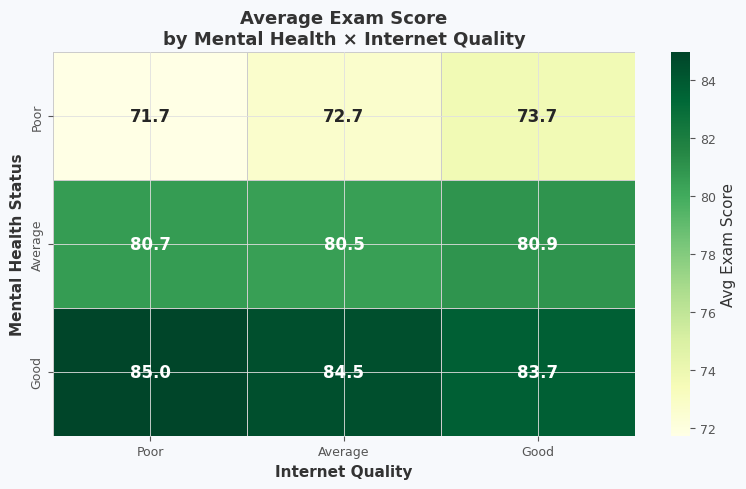

In [ ]:
# Heatmap: Avg Exam Score by Mental Health × Internet Quality

pivot = df.pivot_table(
    values="final_exam_score",
    index="mental_health_status",
    columns="internet_quality",
    aggfunc="mean",
    observed=True
)

pivot = pivot.reindex(index=["Poor", "Average", "Good"],
                      columns=["Poor", "Average", "Good"])

fig10, ax10 = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGn",
            linewidths=0.5, linecolor="#CCCCCC",
            ax=ax10, annot_kws={"size": 12, "fontweight": "bold"},
            cbar_kws={"label": "Avg Exam Score"})
ax10.set_xlabel("Internet Quality", fontweight="bold")
ax10.set_ylabel("Mental Health Status", fontweight="bold")
ax10.set_title("Average Exam Score\nby Mental Health × Internet Quality",
               fontweight="bold")
plt.tight_layout()
plt.show()

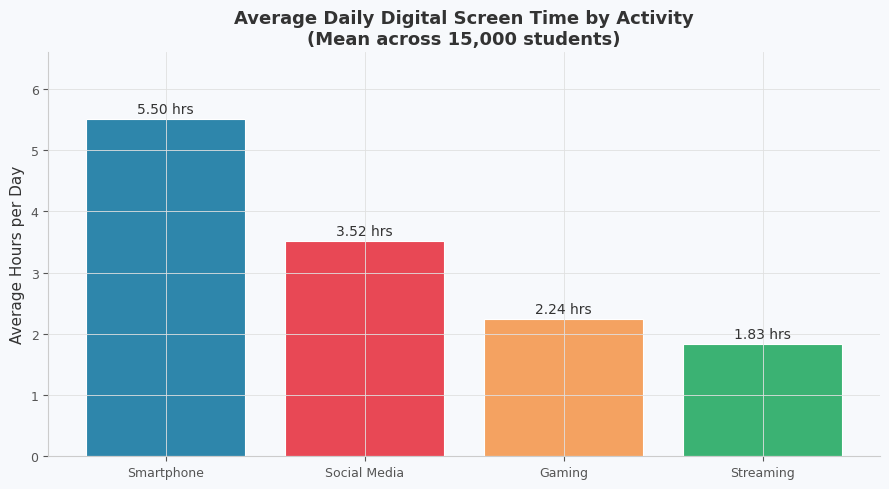

In [ ]:
# Digital Screen Time Breakdown (avg hours by type)
screen_cols = ["smartphone_usage_hours", "social_media_hours",
               "gaming_hours", "streaming_hours"]
screen_labels = ["Smartphone", "Social Media", "Gaming", "Streaming"]
screen_means  = [df[c].mean() for c in screen_cols]

fig11, ax11 = plt.subplots(figsize=(9, 5))
bars11 = ax11.bar(screen_labels, screen_means,
                  color=PALETTE_CAT, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars11, screen_means):
    ax11.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
              f"{val:.2f} hrs", ha="center", va="bottom", fontsize=10)

ax11.set_ylabel("Average Hours per Day")
ax11.set_title("Average Daily Digital Screen Time by Activity\n(Mean across 15,000 students)", fontweight="bold")
ax11.set_ylim(0, max(screen_means) * 1.2)
plt.tight_layout()
plt.show()

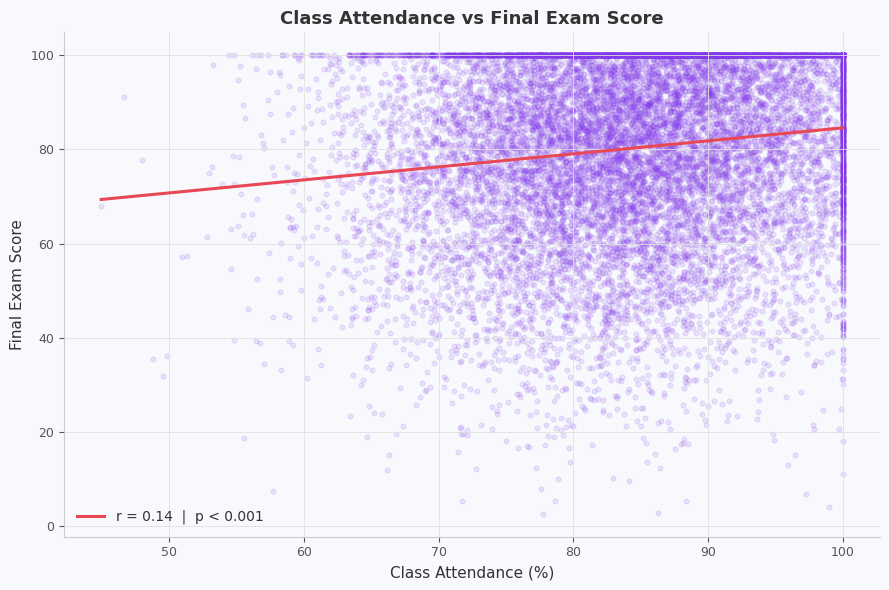

In [ ]:
# CLASS ATTENDANCE vs EXAM SCORE
fig12, ax12 = plt.subplots(figsize=(9, 6))
ax12.scatter(df["class_attendance_percent"], df["final_exam_score"],
             alpha=0.12, s=12, color="#8338EC", rasterized=True)
m3, b3, r3, p3, _ = stats.linregress(
    df["class_attendance_percent"], df["final_exam_score"])
x3 = np.linspace(df["class_attendance_percent"].min(),
                 df["class_attendance_percent"].max(), 200)
ax12.plot(x3, m3 * x3 + b3, color=HIGHLIGHT, linewidth=2.2,
          label=f"r = {r3:.2f}  |  p < 0.001")
ax12.set_xlabel("Class Attendance (%)")
ax12.set_ylabel("Final Exam Score")
ax12.set_title("Class Attendance vs Final Exam Score", fontweight="bold")
ax12.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

**Deep Dive**

In [ ]:
# Bin study hours and show mean score per bin
df["study_tier"] = pd.cut(df["study_hours_per_day"],
                          bins=[0, 2, 4, 6, 12],
                          labels=["<2 hrs", "2–4 hrs", "4–6 hrs", "6+ hrs"])

study_seg = df.groupby("study_tier", observed=True)["final_exam_score"].agg(["mean","std","count"])
print(study_seg)

                 mean        std  count
study_tier                             
<2 hrs      56.367502  17.512777   1381
2–4 hrs     72.472006  17.215964   4506
4–6 hrs     85.583584  13.244707   5550
6+ hrs      93.763864   9.433081   3375


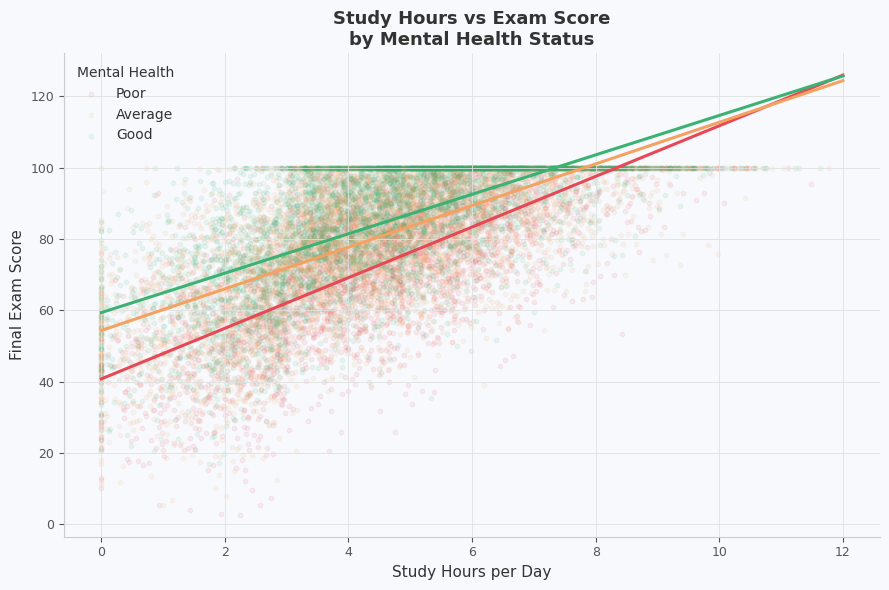

In [ ]:
# Does mental health moderate the study-score relationship?
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))
colors = {"Poor": "#E84855", "Average": "#F4A261", "Good": "#3BB273"}

for status in ["Poor", "Average", "Good"]:
    subset = df[df["mental_health_status"] == status]
    ax.scatter(subset["study_hours_per_day"], subset["final_exam_score"],
               alpha=0.08, s=10, color=colors[status], label=status)
    m, b, _, _, _ = stats.linregress(subset["study_hours_per_day"], subset["final_exam_score"])
    x = np.linspace(0, 12, 100)
    ax.plot(x, m*x + b, color=colors[status], linewidth=2.2)

ax.set_xlabel("Study Hours per Day")
ax.set_ylabel("Final Exam Score")
ax.set_title("Study Hours vs Exam Score\nby Mental Health Status", fontweight="bold")
ax.legend(title="Mental Health", frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
#failing students
failing = df[df["final_exam_score"] < 50]
passing = df[df["final_exam_score"] >= 50]

profile_cols = ["study_hours_per_day", "sleep_hours", "smartphone_usage_hours",
                "social_media_hours", "motivation_level", "class_attendance_percent",
                "assignment_completion_percent", "exercise_hours"]

comparison = pd.DataFrame({
    "Failing (<50)": failing[profile_cols].mean(),
    "Passing (≥50)": passing[profile_cols].mean()
}).round(2)

print(comparison)
print(f"\nFailing students: {len(failing)} ({len(failing)/len(df)*100:.1f}%)")

                               Failing (<50)  Passing (≥50)
study_hours_per_day                     1.94           4.72
sleep_hours                             6.68           7.02
smartphone_usage_hours                  6.41           5.43
social_media_hours                      3.50           3.52
motivation_level                        5.42           6.04
class_attendance_percent               81.97          84.85
assignment_completion_percent          73.93          79.90
exercise_hours                          1.16           1.24

Failing students: 1143 (7.6%)


In [ ]:
df["phone_tier"] = pd.cut(df["smartphone_usage_hours"],
                          bins=[0, 2, 4, 6, 8, 14],
                          labels=["<2h", "2–4h", "4–6h", "6–8h", "8h+"])

phone_seg = df.groupby("phone_tier", observed=True)["final_exam_score"].mean()
print(phone_seg)

phone_tier
<2h     85.708749
2–4h    82.967738
4–6h    80.821823
6–8h    78.604726
8h+     76.358977
Name: final_exam_score, dtype: float64


In [ ]:
df["assign_tier"] = pd.cut(df["assignment_completion_percent"],
                           bins=[0, 60, 75, 90, 100],
                           labels=["Low (<60%)", "Medium (60–75%)", "Good (75–90%)", "High (90%+)"])

assign_seg = df.groupby("assign_tier", observed=True)["final_exam_score"].agg(["mean","count"])
print(assign_seg)

                      mean  count
assign_tier                      
Low (<60%)       72.935592   1402
Medium (60–75%)  77.739605   4051
Good (75–90%)    80.945140   5722
High (90%+)      84.919861   3825


In [ ]:
# Quadrant analysis — 4 groups based on study + phone usage
df["study_high"]  = df["study_hours_per_day"] > df["study_hours_per_day"].median()
df["phone_high"]  = df["smartphone_usage_hours"] > df["smartphone_usage_hours"].median()

df["quadrant"] = "Low Study + High Phone"
df.loc[ df["study_high"] & ~df["phone_high"],  "quadrant"] = "High Study + Low Phone"
df.loc[ df["study_high"] &  df["phone_high"],  "quadrant"] = "High Study + High Phone"
df.loc[~df["study_high"] & ~df["phone_high"],  "quadrant"] = "Low Study + Low Phone"

quad_avg = df.groupby("quadrant")["final_exam_score"].agg(["mean","count"]).round(2)
print(quad_avg.sort_values("mean", ascending=False))

                          mean  count
quadrant                             
High Study + Low Phone   91.03   3737
High Study + High Phone  88.83   3758
Low Study + Low Phone    73.94   3770
Low Study + High Phone   67.58   3735


In [ ]:
sleep_mh = df.groupby("mental_health_status", observed=True)["sleep_hours"].agg(["mean","std","count"])
print(sleep_mh)


df["sleep_adequate"] = df["sleep_hours"] >= 7
combo = df.groupby(["mental_health_status", "sleep_adequate"], observed=True)["final_exam_score"].mean().unstack()
print(combo.round(2))

                          mean       std  count
mental_health_status                           
Poor                  7.007521  1.429633   3026
Average               6.996160  1.476590   6792
Good                  6.993047  1.446814   5182
sleep_adequate        False  True 
mental_health_status              
Poor                  72.23  73.33
Average               79.78  81.54
Good                  83.74  84.96


In [ ]:
gender_profile = df.groupby("gender")[[
    "study_hours_per_day", "smartphone_usage_hours", "social_media_hours",
    "gaming_hours", "sleep_hours", "motivation_level", "final_exam_score"
]].mean().round(2).T
print(gender_profile)

gender                  Female   Male
study_hours_per_day       4.50   4.52
smartphone_usage_hours    5.52   5.49
social_media_hours        3.53   3.51
gaming_hours              2.24   2.24
sleep_hours               6.98   7.01
motivation_level          5.97   6.01
final_exam_score         80.23  80.45


In [ ]:
# Is motivation just a proxy for mental health, or independent?
mh_motiv = df.groupby("mental_health_status", observed=True)["motivation_level"].agg(["mean","std"])
print(mh_motiv)

# Correlation between motivation and exam score within each mental health group
for status in ["Poor", "Average", "Good"]:
    subset = df[df["mental_health_status"] == status]
    r, p = stats.pearsonr(subset["motivation_level"], subset["final_exam_score"])
    print(f"{status}: r={r:.3f}, p={p:.4f}, n={len(subset)}")

                          mean       std
mental_health_status                    
Poor                  6.047723  1.961525
Average               5.983232  1.958324
Good                  5.960000  1.929035
Poor: r=0.153, p=0.0000, n=3026
Average: r=0.175, p=0.0000, n=6792
Good: r=0.156, p=0.0000, n=5182


In [ ]:
# Top 10% scorers vs Bottom 10% scorers
top10    = df[df["final_exam_score"] >= df["final_exam_score"].quantile(0.90)]
bottom10 = df[df["final_exam_score"] <= df["final_exam_score"].quantile(0.10)]

profile_cols = ["study_hours_per_day", "sleep_hours", "smartphone_usage_hours",
                "social_media_hours", "gaming_hours", "streaming_hours",
                "exercise_hours", "motivation_level", "class_attendance_percent",
                "assignment_completion_percent", "caffeine_intake_cups"]

comparison = pd.DataFrame({
    "Top 10%"   : top10[profile_cols].mean(),
    "Bottom 10%": bottom10[profile_cols].mean(),
}).round(2)
comparison["Difference"] = (comparison["Top 10%"] - comparison["Bottom 10%"]).round(2)
print(comparison.sort_values("Difference", ascending=False))

                               Top 10%  Bottom 10%  Difference
assignment_completion_percent    83.42       74.43        8.99
class_attendance_percent         86.63       82.13        4.50
study_hours_per_day               6.22        2.04        4.18
motivation_level                  6.48        5.46        1.02
sleep_hours                       7.11        6.72        0.39
exercise_hours                    1.31        1.17        0.14
social_media_hours                3.54        3.48        0.06
caffeine_intake_cups              1.44        1.42        0.02
streaming_hours                   1.78        1.88       -0.10
gaming_hours                      2.02        2.45       -0.43
smartphone_usage_hours            5.14        6.31       -1.17


In [ ]:
# If students who study more also complete more assignments,
# then assignment completion may just be a proxy for study hours
r_assign_study, _ = stats.pearsonr(df["study_hours_per_day"], df["assignment_completion_percent"])
print(f"Study hours ↔ Assignment completion: r = {r_assign_study:.3f}")

# Also check if assignment completion predicts score AFTER controlling for study hours
# Simple way: within each study tier, does completion still matter?
for tier in ["<2 hrs", "2–4 hrs", "4–6 hrs", "6+ hrs"]:
    subset = df[df["study_tier"] == tier]
    r, p = stats.pearsonr(subset["assignment_completion_percent"], subset["final_exam_score"])
    print(f"  {tier}: assignment completion ↔ score  r={r:.3f}, p={p:.3f}, n={len(subset)}")

Study hours ↔ Assignment completion: r = 0.007
  <2 hrs: assignment completion ↔ score  r=0.295, p=0.000, n=1381
  2–4 hrs: assignment completion ↔ score  r=0.271, p=0.000, n=4506
  4–6 hrs: assignment completion ↔ score  r=0.254, p=0.000, n=5550
  6+ hrs: assignment completion ↔ score  r=0.241, p=0.000, n=3375


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

feature_cols = [
    "study_hours_per_day", "sleep_hours", "smartphone_usage_hours",
    "social_media_hours", "gaming_hours", "streaming_hours",
    "exercise_hours", "motivation_level", "class_attendance_percent",
    "assignment_completion_percent", "mental_health_encoded",
    "internet_quality_encoded"
]

X = df[feature_cols].dropna()
y = df.loc[X.index, "final_exam_score"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)

coef_df = pd.DataFrame({
    "Feature"    : feature_cols,
    "Coefficient": model.coef_.round(3)
}).sort_values("Coefficient", ascending=False)

print(coef_df)
print(f"\nModel R² = {r2_score(y, model.predict(X_scaled)):.3f}")

                          Feature  Coefficient
0             study_hours_per_day       11.849
10          mental_health_encoded        4.021
9   assignment_completion_percent        3.564
7                motivation_level        2.883
8        class_attendance_percent        2.484
1                     sleep_hours        1.412
6                  exercise_hours        1.202
11       internet_quality_encoded        0.170
3              social_media_hours       -0.089
5                 streaming_hours       -0.559
4                    gaming_hours       -1.806
2          smartphone_usage_hours       -2.580

Model R² = 0.582


In [ ]:
df["study_high"] = df["study_hours_per_day"] > df["study_hours_per_day"].median()
df["assign_high"] = df["assignment_completion_percent"] > df["assignment_completion_percent"].median()

combo = df.groupby(["study_high", "assign_high"])["final_exam_score"].agg(["mean","count"])
combo.index = ["Low Study + Low Assign", "Low Study + High Assign",
               "High Study + Low Assign", "High Study + High Assign"]
print(combo.round(2))

                           mean  count
Low Study + Low Assign    67.05   3788
Low Study + High Assign   74.57   3717
High Study + Low Assign   87.61   3716
High Study + High Assign  92.21   3779


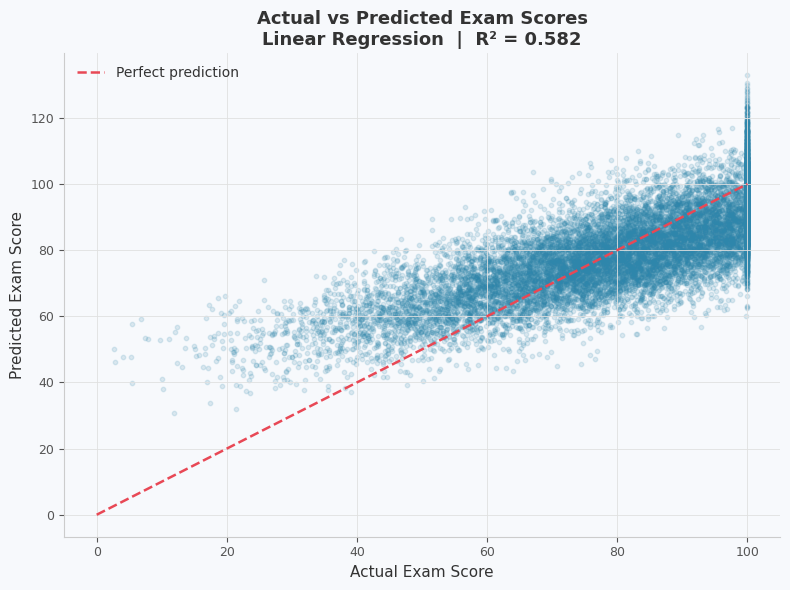

In [ ]:
import matplotlib.pyplot as plt

y_pred = model.predict(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y, y_pred, alpha=0.15, s=10, color="#2E86AB", rasterized=True)
ax.plot([0, 100], [0, 100], color="#E84855", linewidth=1.8, linestyle="--", label="Perfect prediction")
ax.set_xlabel("Actual Exam Score")
ax.set_ylabel("Predicted Exam Score")
ax.set_title(f"Actual vs Predicted Exam Scores\nLinear Regression  |  R² = 0.582", fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()